# Customer Support — Satisfaction Prediction

## Step 1: Problem Definition

Define the goal of predicting the **customer satisfaction score** for a given support ticket. Anticipating customer satisfaction allows support managers to proactively identify frustrated customers and intervene before a negative review is finalized.


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

sns.set_theme(style='whitegrid')
print('Project root:', PROJECT_ROOT)

Project root: c:\Users\jegad\projects\CustomerSupportAnalytics


## Step 2: Data Collection

Load the raw ticket data, which includes historical customer satisfaction ratings. We need examples of past interactions and their resulting satisfaction scores to train the model to recognize the hallmarks of a good or bad experience.


In [2]:
from src.data_loader import load_tickets
raw_df = load_tickets(use_db=True)
raw_df.head()

Loaded 200000 rows from database.


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,None,Debit Card,Spanish,Evening,3,Corporate


## Step 3: Data Cleaning

Clean the dataset to prepare it for a satisfaction prediction task. Removing noise and standardizing the data ensures the model focuses on meaningful predictors rather than formatting errors.


In [3]:
from src.preprocessor import clean_data
cleaned_df = clean_data(raw_df, task_type='satisfaction')
cleaned_df['customer_satisfaction_score'].value_counts().sort_index()

customer_satisfaction_score
1    39756
2    40171
3    40082
4    40086
5    39905
Name: count, dtype: int64

### EDA: Satisfaction by channel

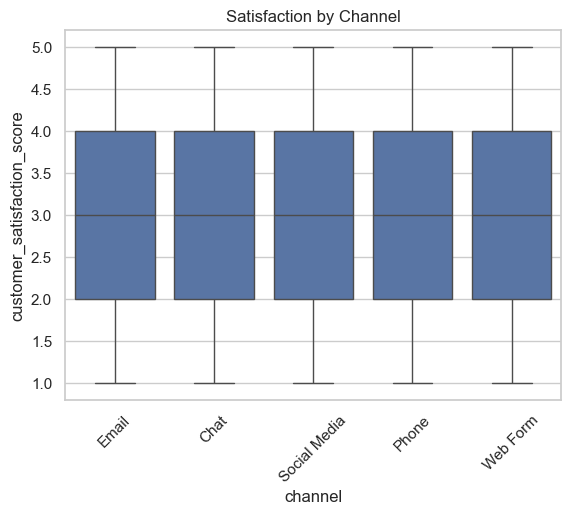

In [4]:
import seaborn as sns
sns.boxplot(data=cleaned_df, x='channel', y='customer_satisfaction_score')
plt.xticks(rotation=45)
plt.title('Satisfaction by Channel')
plt.show()

## Step 4: Feature Engineering

Map the continuous 1-5 satisfaction score into distinct categorical classes (Low, Mid, High) and engineer text features. Predicting an exact score is difficult and less actionable. Grouping scores into categories makes it easier for the model to classify and for the support team to take action on Low predictions.


In [5]:
from src.preprocessor import engineer_features
from src.label_engineering import derive_satisfaction_class

fe_df = engineer_features(cleaned_df, task_type='satisfaction')
fe_df['satisfaction_class'] = derive_satisfaction_class(fe_df)
fe_df = fe_df.sample(min(30000, len(fe_df)), random_state=42)
fe_df['satisfaction_class'].value_counts()

satisfaction_class
Low     19570
Mid      6738
High     3692
Name: count, dtype: int64

## Step 5: Train-Test Split

Isolate the target variable (satisfaction class) and split the data into training and testing sets. This separation is critical to validate that our model can accurately predict the satisfaction of a customer it has never analyzed before.


In [6]:
from sklearn.model_selection import train_test_split

X = fe_df.drop(columns=['satisfaction_class'])
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna('Unknown')
y = fe_df['satisfaction_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape)

Train: (24000, 29)


## Step 6: Model Selection

Test various classification models to see which one best categorizes tickets into Low, Mid, and High satisfaction. Different algorithms handle text and categorical features differently; we compare them to find the most accurate classifier for this specific grouping.


In [7]:
from sklearn.metrics import accuracy_score, f1_score
from src.model_trainer import get_satisfaction_pipelines

for name, pipe in get_satisfaction_pipelines(X_train).items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f"{name}: Acc={accuracy_score(y_test, pred):.4f}  F1={f1_score(y_test, pred, average='weighted'):.4f}")

Logistic Regression: Acc=0.8600  F1=0.8662
Random Forest: Acc=0.9995  F1=0.9995
Neural Network (MLP): Acc=0.9803  F1=0.9804


## Step 7: Model Training

Train the Random Forest classifier on the training dataset. We apply the most successful algorithm to the full training set so it can finalize its understanding of what drives customer satisfaction.


In [8]:
sat = get_satisfaction_pipelines(X_train)['Random Forest']
sat.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## Step 8: Model Evaluation

Assess the model's predictive power using Accuracy, F1-Score, and a detailed classification report. We need to see how well the model predicts each specific class, particularly if it's struggling to identify Low satisfaction tickets, which are the most important to catch.


In [9]:
from sklearn.metrics import classification_report

y_pred = sat.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9995
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       738
         Low       1.00      1.00      1.00      3914
         Mid       1.00      1.00      1.00      1348

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



## Step 9: Model Tuning

Optionally apply Grid Search to hyper-tune the parameters of our satisfaction model. Fine-tuning helps optimize the model's accuracy, ensuring fewer false alarms and more accurate identification of at-risk tickets.


In [10]:
print('Optional GridSearchCV for satisfaction model.')

Optional GridSearchCV for satisfaction model.


## Step 10: Deployment

Save the final satisfaction prediction model bundle using joblib. Deploying this bundle allows our application to automatically flag potentially unhappy customers in real-time as tickets are being processed.


In [11]:
import joblib
from src.paths import get_models_dir

acc = accuracy_score(y_test, y_pred)
joblib.dump({'model': sat, 'model_name': 'Random Forest', 'accuracy': acc},
            os.path.join(get_models_dir(), 'satisfaction_model.pkl'))
print('Saved satisfaction model. Accuracy=', acc)

Saved satisfaction model. Accuracy= 0.9995
